In [3715]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import tqdm
from tqdm import trange
from torch.func import jacfwd, jacrev, vmap
import time
from torch import tensor, sum, log, max, cos, sin, pi, clone, sqrt, mean, std, sort, exp
from scipy.constants import g
from torch import nn

import os
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms

from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

import time

import pandas as pd
from torchvision.io import decode_image

from dpfuncs import *

device = 'cpu' #10x slower running on MPS :(
torch.set_default_device(device)

time elapsed = 3.69, device = cpu


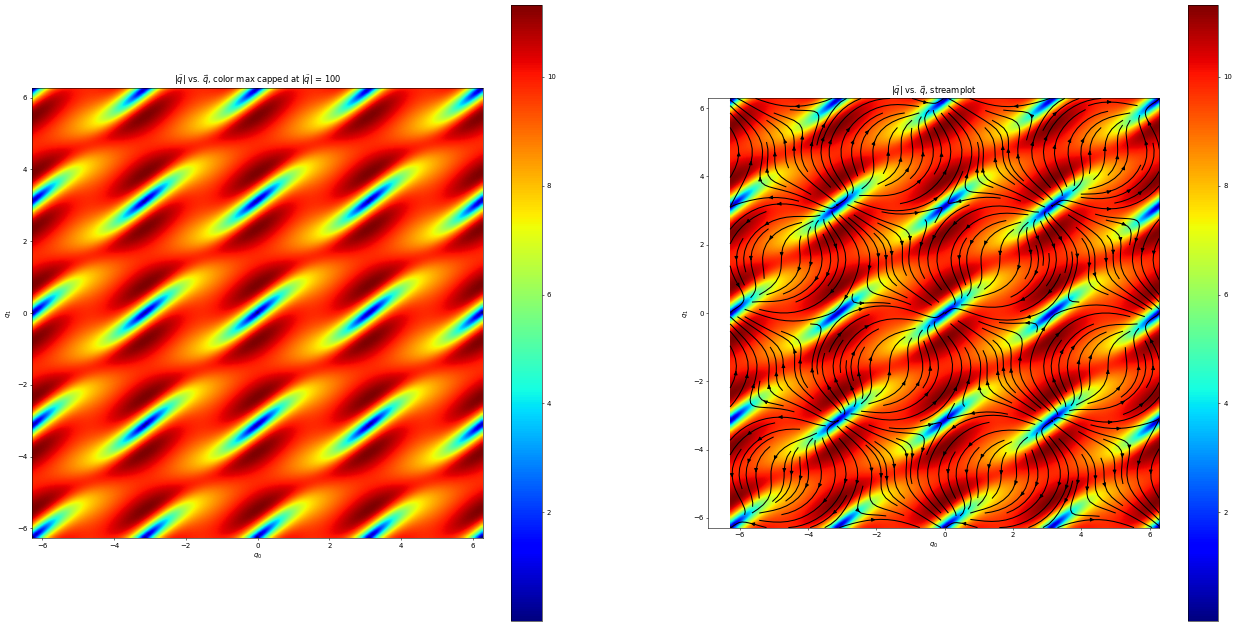

In [4071]:



t1 = time.time()
#####
# problem setup

m1 = torch.tensor([1],dtype=torch.float)
l1 = torch.tensor([1],dtype=torch.float)
m2 = torch.tensor([1],dtype=torch.float)
l2 = torch.tensor([1],dtype=torch.float)

n_points = 175**2

grid_sampling = 1
include_quiver = 0

t0_min = -2*pi
t0_max = 2*pi
t1_min = -2*pi
t1_max = 2*pi

tdot_min = -0
tdot_max = 0


if grid_sampling == 1:
    Qv, QDv = grid_sampling_q_no_qdot(t0_min,t0_max,t1_min,t1_max,n_points)
else:
    Qv, QDv = rand_sampling_q_no_qdot(t0_min,t0_max,t1_min,t1_max,n_points)
n_points = Qv.shape[1]






out = QDDv(Qv,QDv,m1,m2,l1,l2).mT.cpu().detach()
out_true = QDD_true_v(Qv,QDv,m1,m2,l1,l2).cpu().detach()


Qv = Qv.cpu().detach()
QDv = QDv.cpu().detach()


outmag = torch.ones(n_points).cpu().detach()#(out[:,0]**2 + out[:,1]**2)**.5
#print(out)

t_elapsed = time.time() - t1
print(f"time elapsed = {t_elapsed:.2f}, device = {device}")


#####
# plotting

quiver_points = 175**2 #define how many arrows to quiver plot
if quiver_points > n_points: #if specified value greater than number of points analyzed
    quiver_points = n_points #set quiver_points to n_points

n_side = min(tensor([int(sqrt(tensor(n_points))), int(sqrt(tensor(quiver_points)))]) )

t0v = Qv[0,:quiver_points].reshape(n_side,n_side).mT.numpy()
t1v = Qv[1,:quiver_points].reshape(n_side,n_side).mT.numpy()

u = out[0,:quiver_points].reshape(n_side,n_side).numpy()
v = out[1,:quiver_points].reshape(n_side,n_side).numpy()

if grid_sampling == 1:
    if include_quiver == 1:
        fig,axs = plt.subplots(3,1,figsize=(16,32))
        
        #scatter = axs[0].scatter(Qv[0,:],Qv[1,:],c=sqrt(sum(out**2,axis=0)),cmap='jet')
        #plt.colorbar(scatter,ax=axs[0])
        axs[0].quiver(Qv[0,:quiver_points],Qv[1,:quiver_points],out[0,:quiver_points]/outmag[:quiver_points],out[1,:quiver_points]/outmag[:quiver_points])
        axs[0].set_xlabel(r'$q0$')
        axs[0].set_ylabel(r'$q1$')
        axs[0].set_title(r'$\ddot{q}$ unit vectors vs.$q$')
    
        interp_method = 'lanczos'
        cmax = 100
        colors = axs[1].imshow(np.sqrt(out[0,:]**2 + out[1,:]**2).reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points)))),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],origin='lower',cmap='jet',interpolation=interp_method)
        plt.colorbar(colors,ax=axs[1])
        axs[1].set_xlabel(r'$q0$')
        axs[1].set_ylabel(r'$q1$')
        axs[1].set_title(r'$|\ddot{q}|$ vs. $\vec{q}$, color max capped at $|\ddot{q}|$ = ' + f'{cmax}')
        
        
        
        colors = axs[2].imshow(np.sqrt(out[0,:]**2 + out[1,:]**2).reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points)))),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],cmap='jet',interpolation=interp_method,origin='lower')
        plt.colorbar(colors,ax=axs[2])
        axs[2].streamplot(t0v,t1v,v,u,color='black',density=2)
        axs[2].set_xlabel(r'$q_0$')
        axs[2].set_ylabel(r'$q_1$')
        
        plt.show()
    else:
        fig,axs = plt.subplots(1,2,figsize=(32,16))
        
    
        interp_method = 'lanczos'
        cmax = 100
        colors = axs[0].imshow(np.sqrt(out[0,:]**2 + out[1,:]**2).reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points)))),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],origin='lower',cmap='jet',interpolation=interp_method)
        plt.colorbar(colors,ax=axs[0])
        axs[0].set_xlabel(r'$q_0$')
        axs[0].set_ylabel(r'$q_1$')
        axs[0].set_title(r'$|\ddot{q}|$ vs. $\vec{q}$, color max capped at $|\ddot{q}|$ = ' + f'{cmax}')
        
        
        
        colors = axs[1].imshow(np.sqrt(out[0,:]**2 + out[1,:]**2).reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points)))),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],cmap='jet',interpolation=interp_method,origin='lower')
        plt.colorbar(colors,ax=axs[1])
        axs[1].streamplot(t0v,t1v,v,u,color='black',density=2)
        axs[1].set_xlabel(r'$q_0$')
        axs[1].set_ylabel(r'$q_1$')
        axs[1].set_title(r'$|\ddot{q}|$ vs. $\vec{q}$, streamplot')
        
        plt.show()

else:
    fig,axs = plt.subplots(1,2,figsize=(8,16))
    
    #scatter = axs[0].scatter(Qv[0,:],Qv[1,:],c=sqrt(sum(out**2,axis=0)),cmap='jet')
    #plt.colorbar(scatter,ax=axs[0])
    axs[0].quiver(Qv[0,:quiver_points],Qv[1,:quiver_points],out[0,:quiver_points]/outmag[:quiver_points],out[1,:quiver_points]/outmag[:quiver_points])
    axs[0].set_xlabel(r'$q_0$')
    axs[0].set_ylabel(r'$q_1$')
    axs[0].set_title(r'$\ddot{q}$ unit vectors vs.$q$')
    
    cmax = 100
    scatter = axs[1].scatter(Qv[0,:],Qv[1,:],c=sqrt(sum(out**2,axis=0)),cmap='jet')
    plt.colorbar(scatter,ax=axs[1])
    axs[1].set_xlabel(r'$q_0$')
    axs[1].set_ylabel(r'$q_1$')
    axs[1].set_title(r'$|\ddot{q}|$ vs. $\vec{q}$, color max capped at $|\ddot{q}|$ = ' + f'{cmax}')



***Visualize a slice through $\dot{q}$ space***

time elapsed = 0.29, device = cpu


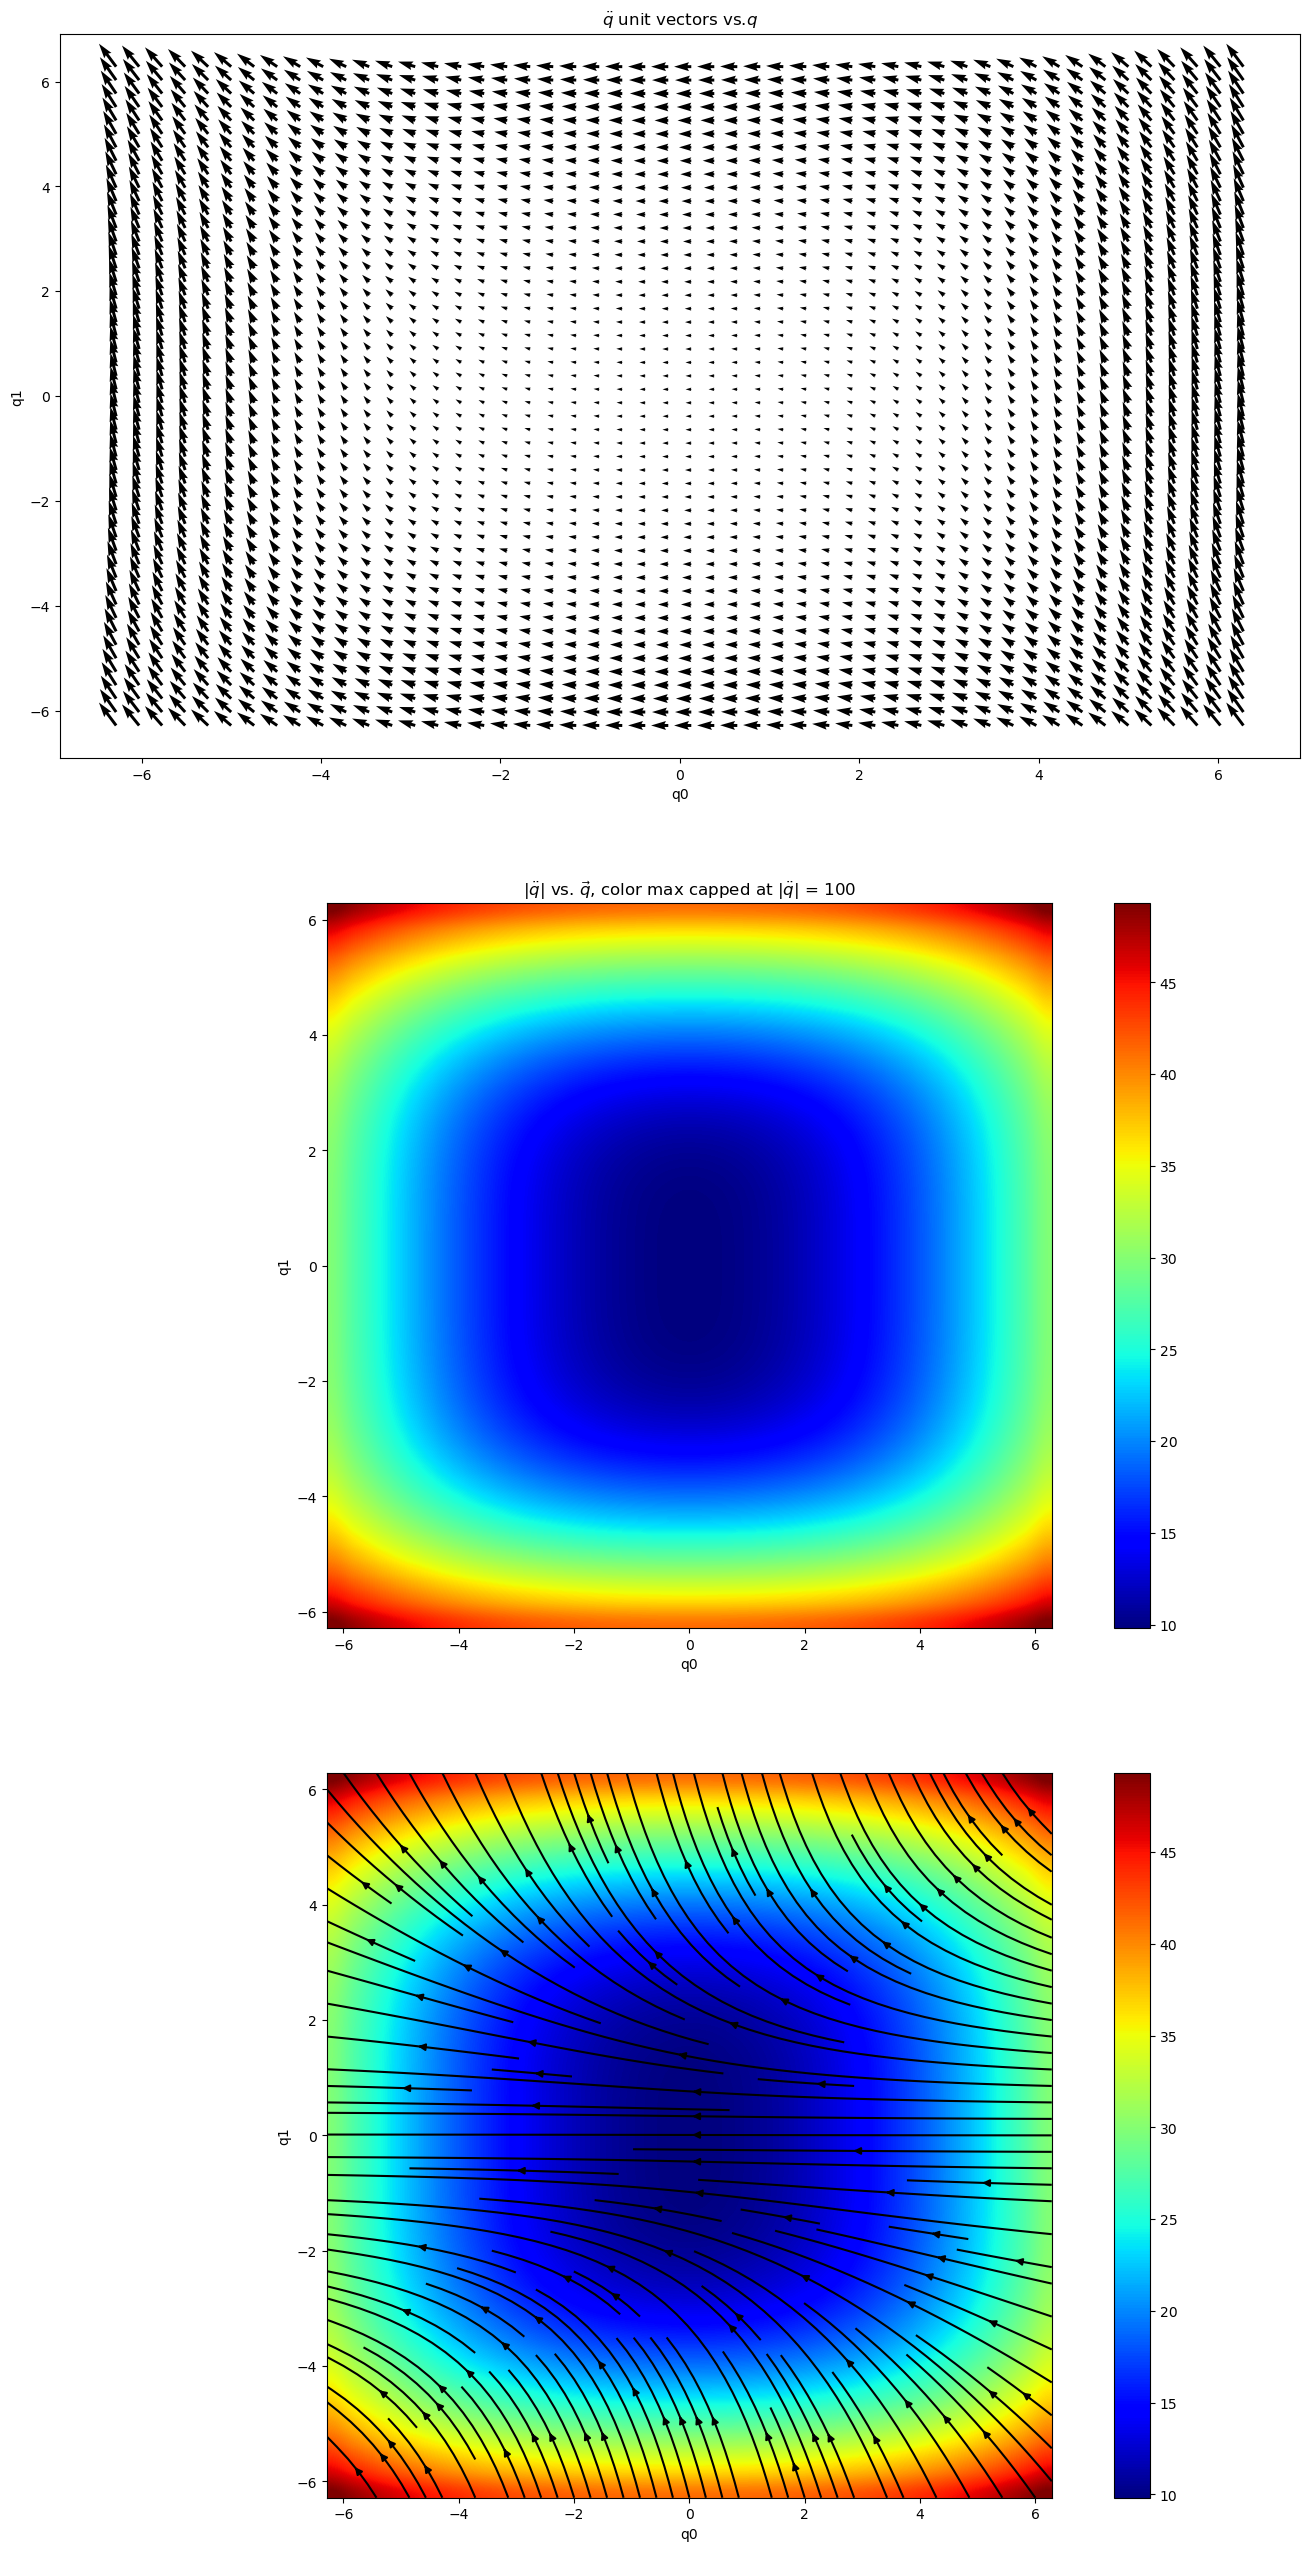

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from torch.func import jacfwd, jacrev, vmap
import time
from torch import tensor, sum, log, max, cos, sin, pi, clone, sqrt, mean, std, sort
from scipy.constants import g
from torch import nn

import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

import time

import pandas as pd
from torchvision.io import decode_image

from dpfuncs import *

dev = 'cpu' #10x slower running on MPS :(
torch.set_default_device(dev)

t1 = time.time()
#####
# problem setup

m1 = torch.tensor([1],dtype=torch.float)
l1 = torch.tensor([1],dtype=torch.float)
m2 = torch.tensor([1],dtype=torch.float)
l2 = torch.tensor([1],dtype=torch.float)

n_points = 50**2

grid_sampling = 1

t_value = tensor([torch.pi/2,0])

tdot0_min = -2*pi
tdot0_max = 2*pi
tdot1_min = -2*pi
tdot1_max = 2*pi


if grid_sampling == 1:
    Qv, QDv = grid_sampling_qdot_with_q(tdot0_min,tdot0_max,tdot1_min,tdot1_max,n_points,t_value)
else:
    Qv, QDv = rand_sampling_qdot_no_q(t0_min,t0_max,t1_min,t1_max,n_points) #need to implement
n_points = Qv.shape[1]





out = QDDv(Qv,QDv,m1,m2,l1,l2).mT.cpu().detach()
out_true = QDD_true_v(Qv,QDv,m1,m2,l1,l2).cpu().detach()

Qv = Qv.cpu().detach()
QDv = QDv.cpu().detach()

outmag = torch.ones(n_points).cpu().detach()#(out[:,0]**2 + out[:,1]**2)**.5

t_elapsed = time.time() - t1
print(f"time elapsed = {t_elapsed:.2f}, device = {dev}")


##########
# plotting

quiver_points = 75**2 #define how many arrows to quiver plot
if quiver_points > n_points: #if specified value greater than number of points analyzed
    quiver_points = n_points #set quiver_points to n_points

n_side = min(tensor([int(sqrt(tensor(n_points))), int(sqrt(tensor(quiver_points)))]) )

td0v = QDv[0,:quiver_points].reshape(n_side,n_side).mT.numpy()
td1v = QDv[1,:quiver_points].reshape(n_side,n_side).mT.numpy()

u = out[0,:quiver_points].reshape(n_side,n_side).numpy()
v = out[1,:quiver_points].reshape(n_side,n_side).numpy()

if grid_sampling == 1:
    fig,axs = plt.subplots(3,1,figsize=(16,32))
    
    #scatter = axs[0].scatter(Qv[0,:],Qv[1,:],c=sqrt(sum(out**2,axis=0)),cmap='jet')
    #plt.colorbar(scatter,ax=axs[0])
    axs[0].quiver(QDv[0,:quiver_points],QDv[1,:quiver_points],out[0,:quiver_points]/outmag[:quiver_points],out[1,:quiver_points]/outmag[:quiver_points])
    axs[0].set_xlabel('q0')
    axs[0].set_ylabel('q1')
    axs[0].set_title(r'$\ddot{q}$ unit vectors vs.$q$')
    
    interp_method = 'lanczos'
    cmax = 100
    colors = axs[1].imshow(np.sqrt(out[0,:]**2 + out[1,:]**2).reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points)))),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],origin='lower',cmap='jet',interpolation=interp_method)
    plt.colorbar(colors,ax=axs[1])
    axs[1].set_xlabel('q0')
    axs[1].set_ylabel('q1')
    axs[1].set_title(r'$|\ddot{q}|$ vs. $\vec{q}$, color max capped at $|\ddot{q}|$ = ' + f'{cmax}')
    
    
    
    colors = axs[2].imshow(np.sqrt(out[0,:]**2 + out[1,:]**2).reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points)))),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],cmap='jet',interpolation=interp_method,origin='lower')
    plt.colorbar(colors,ax=axs[2])
    axs[2].streamplot(t0v,t1v,u,v,color='black',density=1.5)
    axs[2].set_xlabel('q0')
    axs[2].set_ylabel('q1')
    
    plt.show()

else:
    fig,axs = plt.subplots(2,1,figsize=(8,16))
    
    #scatter = axs[0].scatter(Qv[0,:],Qv[1,:],c=sqrt(sum(out**2,axis=0)),cmap='jet')
    #plt.colorbar(scatter,ax=axs[0])
    axs[0].quiver(Qv[0,:quiver_points],Qv[1,:quiver_points],out[0,:quiver_points]/outmag[:quiver_points],out[1,:quiver_points]/outmag[:quiver_points])
    axs[0].set_xlabel('q0')
    axs[0].set_ylabel('q1')
    axs[0].set_title(r'$\ddot{q}$ unit vectors vs.$q$')
    
    cmax = 100
    scatter = axs[1].scatter(Qv[0,:],Qv[1,:],c=sqrt(sum(out**2,axis=0)),cmap='jet')
    plt.colorbar(scatter,ax=axs[1])
    axs[1].set_xlabel('q0')
    axs[1].set_ylabel('q1')
    axs[1].set_title(r'$|\ddot{q}|$ vs. $\vec{q}$, color max capped at $|\ddot{q}|$ = ' + f'{cmax}')



***Prepare synthetic dataset***

In [2862]:
n_points = 64*128*8
batch_size = 8*64

m1 = torch.tensor([1],dtype=torch.float)
l1 = torch.tensor([1],dtype=torch.float)
m2 = torch.tensor([1],dtype=torch.float)
l2 = torch.tensor([1],dtype=torch.float)

grid_sampling = 0
full_sampling = 1
q_sampling = 0
qdot_sampling = 0


t_value = tensor([torch.pi/2,0])

t_scale = 2.2
t0_min = -t_scale*pi
t0_max = t_scale*pi
t1_min = -t_scale*pi
t1_max = t_scale*pi

tdot_scale = 4
tdot0_min = -tdot_scale*pi
tdot0_max = tdot_scale*pi
tdot1_min = -tdot_scale*pi
tdot1_max = tdot_scale*pi

if grid_sampling == 1:
    if q_sampling == 1:
        Qv, QDv = grid_sampling_q_no_qdot(t0_min,t0_max,t1_min,t1_max,n_points)
    elif qdot_sampling == 1:     
        Qv, QDv = grid_sampling_qdot_with_q(tdot0_min,tdot0_max,tdot1_min,tdot1_max,n_points,t_value)
else:
    if q_sampling == 1:
        Qv, QDv = rand_sampling_q_no_qdot(t0_min,t0_max,t1_min,t1_max,n_points,tdot0_min,tdot0_max)
    elif qdot_sampling == 1:
        Qv, QDv = rand_sampling_qdot_no_q(tdot0_min,tdot0_max,tdot1_min,tdot1_max,n_points,t0_min,t1_max)
    elif full_sampling == 1:
        Qv, QDv = rand_sampling_full(t0_min,t0_max,t1_min,t1_max,tdot0_min,tdot0_max,tdot1_min,tdot1_max,n_points)

n_points = Qv.shape[1]

out_true = QDD_true_v(Qv,QDv,m1,m2,l1,l2).cpu().detach()

Qv = Qv.cpu().detach()
QDv = QDv.cpu().detach()

Q_full = torch.cat((Qv,QDv))
dataset = TensorDataset(Q_full.mT,out_true.mT)


if device == 'mps':
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0,pin_memory=False, drop_last=True)
else:
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0,pin_memory=True, drop_last=True)

print('Sampling complete.')

Sampling complete.


In [2671]:
l1 = 512
l2 = 512
l3 = 512
l4 = 512
l5 = 512

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        #self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(4, l1),
            nn.ReLU(),
            nn.Linear(l1, l2),
            nn.ReLU(),
            nn.Linear(l2, l3),
            nn.ReLU(),
            nn.Linear(l3, l4),
            nn.ReLU(),
            nn.Linear(l4, l5),
            nn.ReLU(),
            nn.Linear(l5, 2),
        )

    def forward(self, x):
        q = x[:2]
        qd = x[2:]
        q = torch.fmod(q,2*torch.pi)
        x = torch.cat((q,qd))
        qdd = self.linear_relu_stack(x)
        return qdd

model = NeuralNetwork().to(device)

def train_loop(dataloader, model, loss_fn, optimizer, print_option = False):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    loss_sum = 0
    for batch, (X, y) in enumerate(dataloader):
        #X = X.to(device)
        #y = y.to(device)
        # Compute prediction and loss
        pred = model(X.to(device))
        loss = loss_fn(pred, y.to(device))
        loss_sum += loss
        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        if batch % 100 == 0 and print_option != False:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    return loss_sum


100%|██████████| 8000/8000 [37:13<00:00,  3.58it/s]     


Minimum loss: 3.0e-01


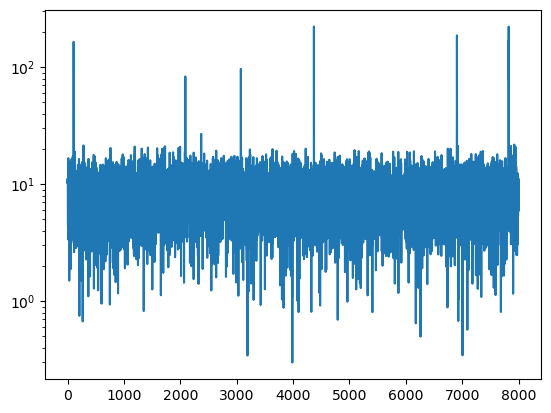

In [3678]:
learning_rate = 3e-4
num_epochs = 8000

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
#optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for x, y in dataloader:
    x  = x.to(device)
    y = y.to(device)

loss_history = np.inf*np.ones(num_epochs)
saved_epochs = [0]

torch.save(model.state_dict(), 'working_best_params')
for i in trange(num_epochs):
    #print(f"EPOCH {i} -----------------------")
    loss_history[i] = train_loop(dataloader, model, loss_fn, optimizer)
    if loss_history[i] <= min(loss_history):
        torch.save(model.state_dict(), 'working_best_params')
        saved_epochs.append(i)

#print(saved_epochs)
print(f"Minimum loss: {min(loss_history):.1e}")
model.load_state_dict(torch.load('working_best_params', weights_only=True))
plt.plot(loss_history)
plt.yscale('log')

label: linear_relu_stack.0.weight


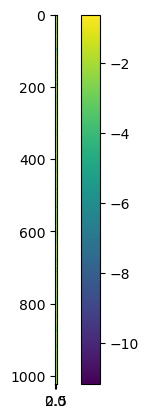

label: linear_relu_stack.2.weight


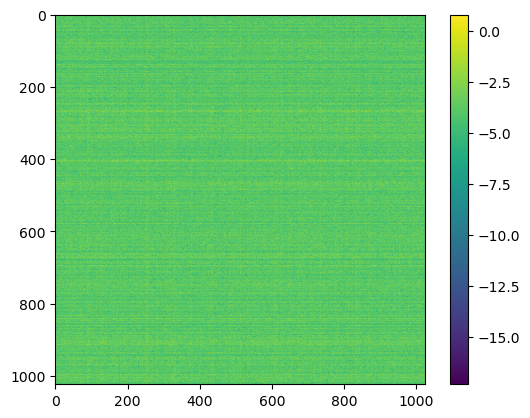

label: linear_relu_stack.4.weight


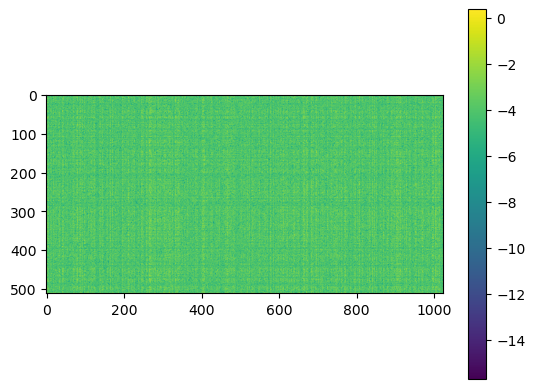

label: linear_relu_stack.6.weight


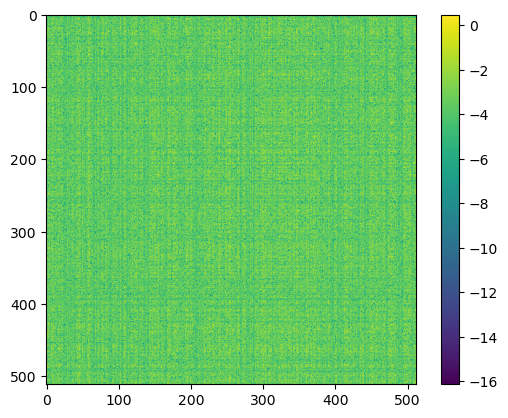

label: linear_relu_stack.8.weight


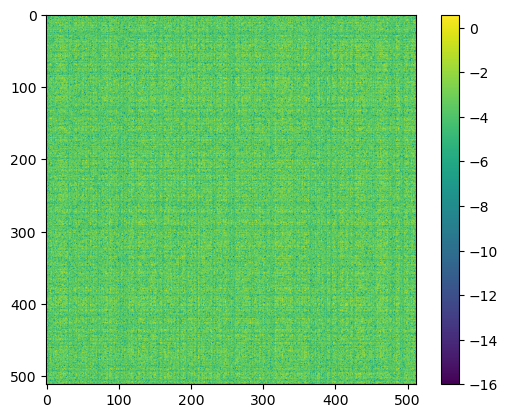

label: linear_relu_stack.10.weight


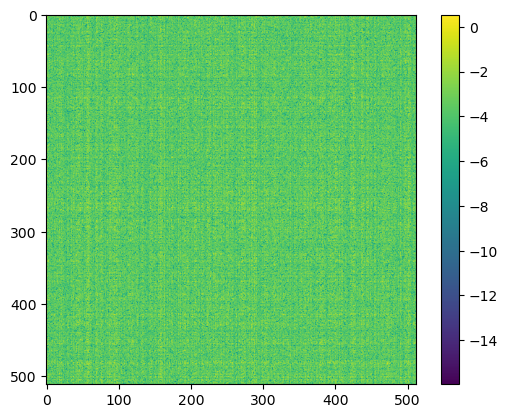

label: linear_relu_stack.12.weight


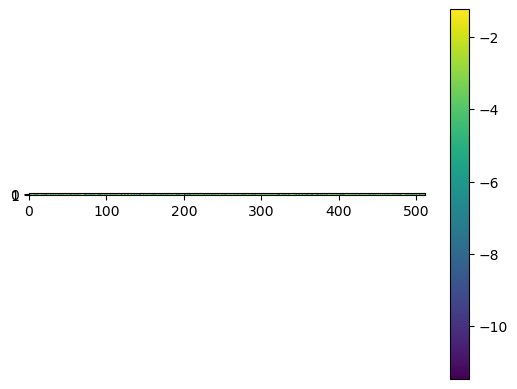

In [3068]:
for i in model.state_dict():
    if not( 'bias' in i):
        #print(f"label: {i}, data: {model.state_dict()[i]}")
        print(f"label: {i}")
        plt.imshow(log(abs(model.state_dict()[i])))
        plt.colorbar()
        plt.show()

#model.state_dict()

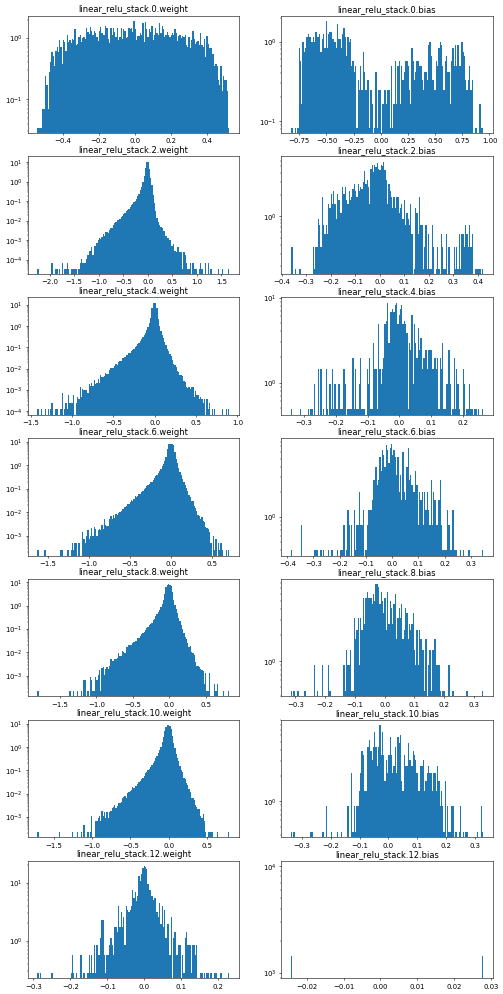

In [3995]:
fig, axs = plt.subplots(int(len(model.state_dict())/2),2, figsize = (12,25))

count = 0
for i in model.state_dict():
    axs[int(count/2),count%2].hist(model.state_dict()[i].reshape(-1),bins=150,align='mid',density=True)
    axs[int(count/2),count%2].set_title(f"{i}")
    axs[int(count/2),count%2].set_yscale('log')
    count += 1
plt.show()

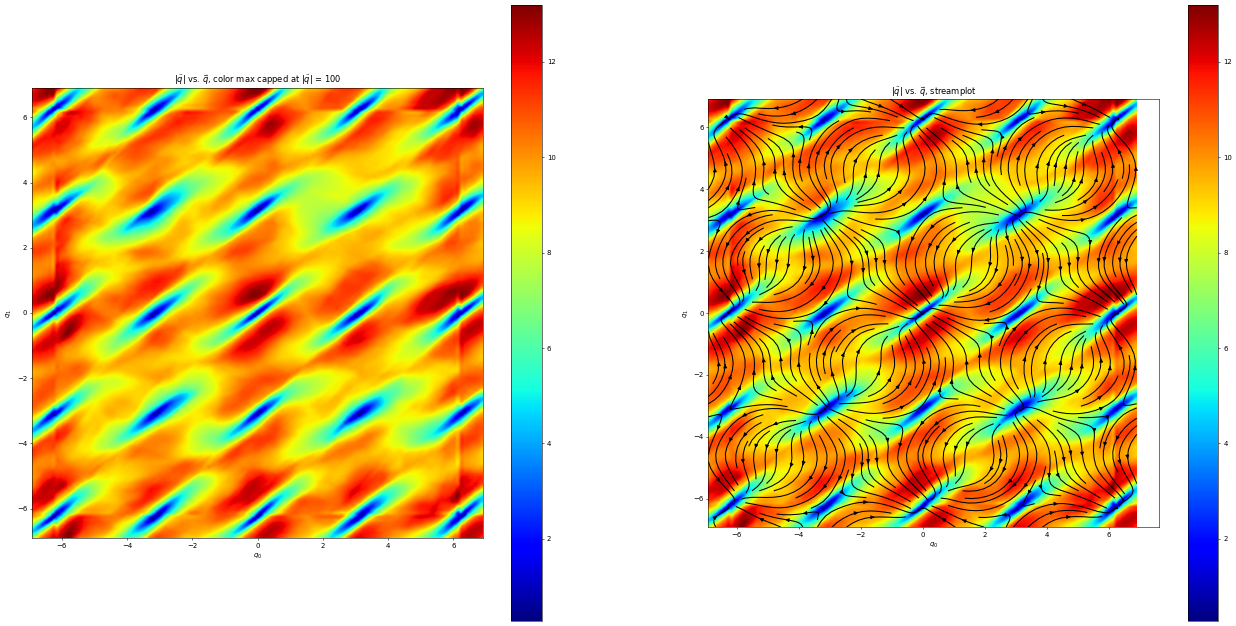

In [4073]:
n_points = 155**2

grid_sampling = 1
include_quiver = 0

t_plot_scale = 2.2
t0_min = -t_plot_scale*pi
t0_max = t_plot_scale*pi
t1_min = -t_plot_scale*pi
t1_max = t_plot_scale*pi

tdot_min = -0
tdot_max = 0


if grid_sampling == 1:
    Qv, QDv = grid_sampling_q_no_qdot(t0_min,t0_max,t1_min,t1_max,n_points)
else:
    Qv, QDv = rand_sampling_q_no_qdot(t0_min,t0_max,t1_min,t1_max,n_points)
n_points = Qv.shape[1]

modelv = vmap(model,in_dims=(1))

Qtot = torch.cat((Qv,QDv))



#out = QDDv(Qv,QDv,m1,m2,l1,l2).mT.cpu().detach()
#out_true = QDD_true_v(Qv,QDv,m1,m2,l1,l2).cpu().detach()

model.eval()
out = modelv(Qtot).mT.cpu().detach()
model.train()

out_true = QDD_true_v(Qv,QDv,m1,m2,l1,l2).cpu().detach()

Qv = Qv.cpu().detach()
QDv = QDv.cpu().detach()


outmag = torch.ones(n_points).cpu().detach()#(out[:,0]**2 + out[:,1]**2)**.5
#print(out)

#t_elapsed = time.time() - t1
#print(f"time elapsed = {t_elapsed:.2f}, device = {dev}")


#####
# plotting

quiver_points = 175**2 #define how many arrows to quiver plot
if quiver_points > n_points: #if specified value greater than number of points analyzed
    quiver_points = n_points #set quiver_points to n_points

n_side = min(tensor([int(sqrt(tensor(n_points))), int(sqrt(tensor(quiver_points)))]) )

t0v = Qv[0,:quiver_points].reshape(n_side,n_side).mT.numpy()
t1v = Qv[1,:quiver_points].reshape(n_side,n_side).mT.numpy()

u = out[0,:quiver_points].reshape(n_side,n_side).numpy()
v = out[1,:quiver_points].reshape(n_side,n_side).numpy()

if grid_sampling == 1:
    if include_quiver == 1:
        fig,axs = plt.subplots(3,1,figsize=(16,32))
        
        #scatter = axs[0].scatter(Qv[0,:],Qv[1,:],c=sqrt(sum(out**2,axis=0)),cmap='jet')
        #plt.colorbar(scatter,ax=axs[0])
        axs[0].quiver(Qv[0,:quiver_points],Qv[1,:quiver_points],out[0,:quiver_points]/outmag[:quiver_points],out[1,:quiver_points]/outmag[:quiver_points])
        axs[0].set_xlabel(r'$q_0$')
        axs[0].set_ylabel(r'$q_1$')
        axs[0].set_title(r'$\ddot{q}$ unit vectors vs.$q$')
    
        interp_method = 'lanczos'
        cmax = 100
        colors = axs[1].imshow(np.sqrt(out[0,:]**2 + out[1,:]**2).reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points)))),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],origin='lower',cmap='jet',interpolation=interp_method)
        plt.colorbar(colors,ax=axs[1])
        axs[1].set_xlabel(r'$q_0$')
        axs[1].set_ylabel(r'$q_1$')
        axs[1].set_title(r'$|\ddot{q}|$ vs. $\vec{q}$, color max capped at $|\ddot{q}|$ = ' + f'{cmax}')
        
        
        
        colors = axs[2].imshow(np.sqrt(out[0,:]**2 + out[1,:]**2).reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points)))),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],cmap='jet',interpolation=interp_method,origin='lower')
        plt.colorbar(colors,ax=axs[2])
        axs[2].streamplot(t0v,t1v,v,u,color='black',density=2)
        axs[2].set_xlabel(r'$q_0$')
        axs[2].set_ylabel(r'$q_1$')
        
        plt.show()
    else:
        fig,axs = plt.subplots(1,2,figsize=(32,16))
        
    
        interp_method = 'lanczos'
        cmax = 100
        colors = axs[0].imshow(np.sqrt(out[0,:]**2 + out[1,:]**2).reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points)))),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],origin='lower',cmap='jet',interpolation=interp_method)
        plt.colorbar(colors,ax=axs[0])
        axs[0].set_xlabel(r'$q_0$')
        axs[0].set_ylabel(r'$q_1$')
        axs[0].set_title(r'$|\ddot{q}|$ vs. $\vec{q}$, color max capped at $|\ddot{q}|$ = ' + f'{cmax}')
        
        
        
        colors = axs[1].imshow(np.sqrt(out[0,:]**2 + out[1,:]**2).reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points)))),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],cmap='jet',interpolation=interp_method,origin='lower')
        plt.colorbar(colors,ax=axs[1])
        axs[1].streamplot(t0v,t1v,v,u,color='black',density=2)
        axs[1].set_xlabel(r'$q_0$')
        axs[1].set_ylabel(r'$q_1$')
        axs[1].set_title(r'$|\ddot{q}|$ vs. $\vec{q}$, streamplot')
        
        plt.show()

else:
    fig,axs = plt.subplots(2,1,figsize=(8,16))
    
    #scatter = axs[0].scatter(Qv[0,:],Qv[1,:],c=sqrt(sum(out**2,axis=0)),cmap='jet')
    #plt.colorbar(scatter,ax=axs[0])
    axs[0].quiver(Qv[0,:quiver_points],Qv[1,:quiver_points],out[0,:quiver_points]/outmag[:quiver_points],out[1,:quiver_points]/outmag[:quiver_points])
    axs[0].set_xlabel(r'$q0$')
    axs[0].set_ylabel(r'$q1$')
    axs[0].set_title(r'$\ddot{q}$ unit vectors vs.$q$')
    
    cmax = 100
    scatter = axs[1].scatter(Qv[0,:],Qv[1,:],c=sqrt(sum(out**2,axis=0)),cmap='jet')
    plt.colorbar(scatter,ax=axs[1])
    axs[1].set_xlabel(r'$q0$')
    axs[1].set_ylabel(r'$q1$')
    axs[1].set_title(r'$|\ddot{q}|$ vs. $\vec{q}$, color max capped at $|\ddot{q}|$ = ' + f'{cmax}')



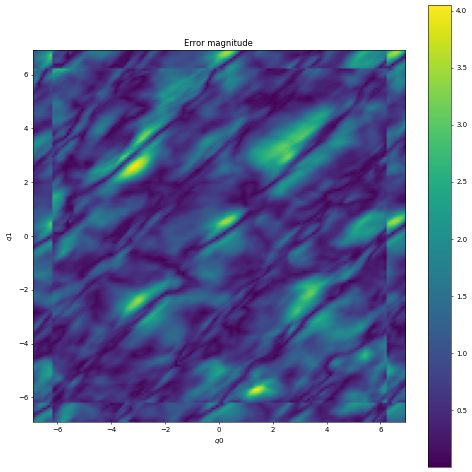

In [4064]:
#plt.imshow( sqrt(sum((out-out_true)**2,axis=0)).reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points)))),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],origin='lower' )
#out_true = QDD_true_v(Qv,QDv,m1,m2,l1,l2).cpu().detach()

#diff = sqrt( (out[0,:] - out_true[0,:])**2 + (out[1,:] - out_true[1,:])**2)
od0 = out[0,:].reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points))))
od1 = out[1,:].reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points))))

otd0 = out_true[0,:].reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points))))
otd1 = out_true[1,:].reshape(int(sqrt(tensor(n_points))),int(sqrt(tensor(n_points))))

diff = sqrt( (od0-otd0)**2 + (od1-otd1)**2 )
#diff = otd

fig, axs = plt.subplots(1,1,figsize=(12,12))
cb = axs.imshow( (diff),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],origin='lower' )
#plt.imshow( np.log(diff),extent=[t0v.min(),t0v.max(),t1v.min(),t1v.max()],origin='lower' )
#plt.imshow(sqrt(otd0**2+otd1**2),origin='lower')
axs.set_xlabel(r'$q0$')
axs.set_ylabel(r'$q1$')
axs.set_title(r'Error magnitude')

plt.colorbar(cb, ax=axs)
plt.show()

In [3686]:
print(max(out_true))

tensor(10.4)


In [4003]:
PATH = '10th_dp_model'
torch.save(model.state_dict(), PATH)
print('Saving complete.')

Saving complete.


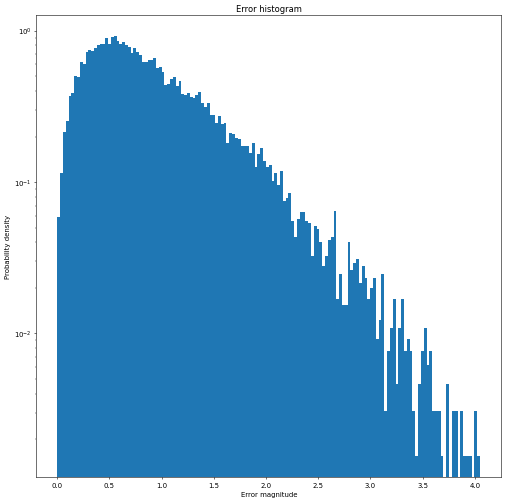

In [4067]:
fig,axs=plt.subplots(1,1,figsize=(12,12))

axs.hist(diff.reshape(-1),density=True,bins=150)
axs.set_yscale('log')
axs.set_xlabel('Error magnitude')
axs.set_ylabel('Probability density')
axs.set_title('Error histogram')
plt.show()

In [3089]:
abs(out_true).max()

tensor(1.0e+01)

100%|██████████| 10/10 [00:55<00:00,  5.57s/it]


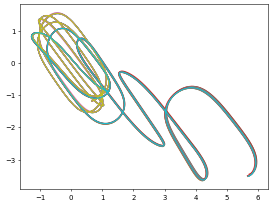

In [3993]:
#Euler stepping

def qdd_fixed(qtot):
    return QDD_true(qtot[:2],qtot[2:],m1,m2,l1,l2)

n_euler_iterations = 20000
n_conditions = 10

cond_spread = 0.001
#cond_mean = tensor([torch.pi/2,torch.pi/2,0,0])
cond_mean = torch.randn(4)

tmax = 10

h = tmax/n_euler_iterations

model.eval()


for cond in trange(n_conditions):
    qtot = cond_spread*torch.randn(4) + cond_mean
    qtot_model = cond_spread*torch.randn(4) + cond_mean
    
    qstore = torch.zeros(4,n_euler_iterations)
    qstore[:,0] = qtot
    qstore_model = torch.zeros(4,n_euler_iterations)
    qstore_model[:,0] = qtot_model
    
    for i in range(1,n_euler_iterations):
        qdd_model = model(qtot)
        qdd = qdd_fixed(qtot)
        qtot[:2] += h*qtot[2:]
        qtot[2:] += h*qdd
        qstore[:,i] = qtot
        qtot_model[:2] += h*qtot_model[2:]
        qtot_model[2:] += h*qdd_model
        qstore_model[:,i] = qtot_model
    qstore = qstore.cpu().detach().numpy()
    qstore_model = qstore_model.cpu().detach().numpy()
    plt.plot(qstore[0,:],qstore[1,:],label=f"true condition: {cond}")
    plt.plot(qstore_model[0,:],qstore_model[1,:],label=f"model condition: {cond}")


"""
qtot = cond_mean
qstore = torch.zeros(4,n_euler_iterations)
qstore[:,0] = qtot
for i in range(1,n_euler_iterations):
    qdd = model(qtot)
    qtot[:2] += h*qtot[2:]
    qtot[2:] += h*qdd
    qstore[:,i] = qtot
qstore = qstore.cpu().detach().numpy()
plt.plot(qstore[0,:],qstore[1,:],label=f"condition: center")
"""

#plt.legend(loc='right')
plt.show()


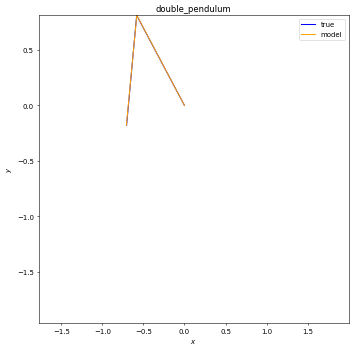

In [3889]:
duration = 3 #playback duration
frame_rate = 20 #playback framerate
n_frames = n_euler_iterations #calculate total number of frames
fig_dpi = 50


#convert to pendulum positions instead of angles
qstore = tensor(qstore)
x1 = l1*sin(qstore[0,:])
x2 = l1*sin(qstore[0,:]) + l2*sin(qstore[1,:])
y1 = -l1*cos(qstore[0,:])
y2 = -l1*cos(qstore[0,:]) - l2*cos(qstore[1,:])

qstore_model = tensor(qstore_model)
x1_model = l1*sin(qstore_model[0,:])
x2_model = l1*sin(qstore_model[0,:]) + l2*sin(qstore_model[1,:])
y1_model = -l1*cos(qstore_model[0,:])
y2_model = -l1*cos(qstore_model[0,:]) - l2*cos(qstore_model[1,:])

#plt.plot(x1,y1)
#plt.plot(x2,y2)
#plt.show()

plt.rcParams["animation.html"] = "jshtml" #set animation backend
plt.rcParams['figure.dpi'] = fig_dpi #set figure dpi

fig, ax = plt.subplots(1,1,figsize=(8,8)) #create subplot object

def animate(i): #define animation routine
    #i = 5*i
    #each frame:
    ax.cla() #clear the plot
    ax.plot([0,x1[i],x2[i]],[0,y1[i],y2[i]],label='true',color='blue')
    ax.plot([0,x1_model[i],x2_model[i]],[0,y1_model[i],y2_model[i]],label=r'model',color='orange')
    ax.set_xlim(min(min(x1),min(x2)),max(max(x1),max(x2))) #plot formatting
    ax.set_ylim(min(min(y1),min(y2)),max(max(y1),max(y2)))

    ax.legend() #plot formatting
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_title(r'double_pendulum')

animation.FuncAnimation(fig, animate, frames=n_frames, interval = 1000/frame_rate) #trigger animation



100%|██████████| 1/1 [00:00<00:00,  5.41it/s]


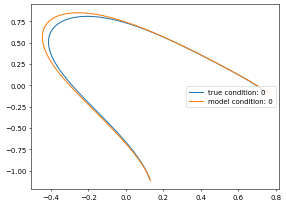

MovieWriter ffmpeg unavailable; using Pillow instead.


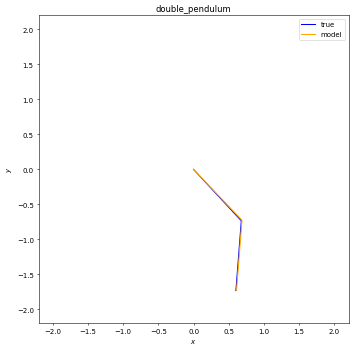

In [4101]:
#Big animation


plot_true  = 1
plot_model = 1

def qdd_fixed(qtot):
    return QDD_true(qtot[:2],qtot[2:],m1,m2,l1,l2)

n_euler_iterations = 600
n_conditions = 1

cond_spread = 0.0125
#cond_mean = tensor([torch.pi/2,torch.pi/2,0,0])
cond_mean = torch.randn(4)

tmax = 1.2

h = tmax/n_euler_iterations

model.eval()

if (plot_true == 0) and (plot_model == 0):
    print('Pick at least one type of run to plot.')
    sys.exit()

if plot_true == 1:
    qstore_true_full = torch.zeros([n_conditions,4,n_euler_iterations])
if plot_model == 1:
    qstore_model_full = torch.zeros([n_conditions,4,n_euler_iterations])


for cond in trange(n_conditions):
    if plot_true == 1:
        qtot = cond_spread*torch.randn(4) + cond_mean
        qstore = torch.zeros(4,n_euler_iterations)
        qstore[:,0] = qtot
    if plot_model == 1:
        qtot_model = cond_spread*torch.randn(4) + cond_mean
        qstore_model = torch.zeros(4,n_euler_iterations)
        qstore_model[:,0] = qtot_model


    #euler iteration
    for i in range(1,n_euler_iterations):
        if plot_true == 1:
            qdd = qdd_fixed(qtot)
            qtot[:2] += h*qtot[2:]
            qtot[2:] += h*qdd
            qstore[:,i] = qtot
        if plot_model == 1:
            qdd_model = model(qtot)
            qtot_model[:2] += h*qtot_model[2:]
            qtot_model[2:] += h*qdd_model
            qstore_model[:,i] = qtot_model

    if plot_true == 1:
        qstore_true_full[cond,:,:] = qstore
        qstore = qstore.cpu().detach().numpy()
        plt.plot(qstore[0,:],qstore[1,:],label=f"true condition: {cond}")
    if plot_model == 1:
        qstore_model_full[cond,:,:] = qstore_model
        qstore_model = qstore_model.cpu().detach().numpy()
        plt.plot(qstore_model[0,:],qstore_model[1,:],label=f"model condition: {cond}")

if (plot_true == 1) or (plot_model == 1):
    plt.legend(loc='right')
    plt.show()

duration = 3 #playback duration
frame_rate = 20 #playback framerate
n_frames = n_euler_iterations #calculate total number of frames
fig_dpi = 50


#convert to pendulum positions instead of angles
if plot_true == 1:
    x1_true_full = torch.zeros(n_conditions,n_euler_iterations)
    x2_true_full = torch.zeros(n_conditions,n_euler_iterations)
    y1_true_full = torch.zeros(n_conditions,n_euler_iterations)
    y2_true_full = torch.zeros(n_conditions,n_euler_iterations)

if plot_model == 1:
    x1_model_full = torch.zeros(n_conditions,n_euler_iterations)
    x2_model_full = torch.zeros(n_conditions,n_euler_iterations)
    y1_model_full = torch.zeros(n_conditions,n_euler_iterations)
    y2_model_full = torch.zeros(n_conditions,n_euler_iterations)

for cond in range(n_conditions):
    if plot_true == 1:
        x1_true_full[cond,:] = l1*sin(qstore_true_full[cond,0,:])
        x2_true_full[cond,:] = l1*sin(qstore_true_full[cond,0,:]) + l2*sin(qstore_true_full[cond,1,:])
        y1_true_full[cond,:] = -l1*cos(qstore_true_full[cond,0,:])
        y2_true_full[cond,:] = -l1*cos(qstore_true_full[cond,0,:]) - l2*cos(qstore_true_full[cond,1,:])
    if plot_model == 1:
        x1_model_full[cond,:] = l1*sin(qstore_model_full[cond,0,:])
        x2_model_full[cond,:] = l1*sin(qstore_model_full[cond,0,:]) + l2*sin(qstore_true_full[cond,1,:])
        y1_model_full[cond,:] = -l1*cos(qstore_model_full[cond,0,:])
        y2_model_full[cond,:] = -l1*cos(qstore_model_full[cond,0,:]) - l2*cos(qstore_true_full[cond,1,:])

if plot_true == 1 and plot_model == 1: #both case
    bulk_store_x = torch.zeros([n_conditions,4,n_euler_iterations])
    bulk_store_x[:,0,:] = x1_true_full
    bulk_store_x[:,1,:] = x2_true_full
    bulk_store_x[:,2,:] = x1_model_full
    bulk_store_x[:,3,:] = x2_model_full
    bulk_store_y = torch.zeros([n_conditions,4,n_euler_iterations])
    bulk_store_y[:,0,:] = y1_true_full
    bulk_store_y[:,1,:] = y2_true_full
    bulk_store_y[:,2,:] = y1_model_full
    bulk_store_y[:,3,:] = y2_model_full

    #detach everything from computational graph
    bulk_store_x = bulk_store_x.detach()
    bulk_store_y = bulk_store_y.detach()
    x1_true_full = x1_true_full.detach()
    x2_true_full = x2_true_full.detach()
    y1_true_full = y1_true_full.detach()
    y2_true_full = y2_true_full.detach()
    x1_model_full = x1_model_full.detach()
    x2_model_full = x2_model_full.detach()
    y1_model_full = y1_model_full.detach()
    y2_model_full = y2_model_full.detach()
elif (plot_true == 1) and (plot_model != 1): #only true case
    bulk_store_x = torch.zeros([n_conditions,2,n_euler_iterations])
    bulk_store_x[:,0,:] = x1_true_full
    bulk_store_x[:,1,:] = x2_true_full
    bulk_store_y = torch.zeros([n_conditions,2,n_euler_iterations])
    bulk_store_y[:,0,:] = y1_true_full
    bulk_store_y[:,1,:] = y2_true_full

    #detach everything from computational graph
    bulk_store_x = bulk_store_x.detach()
    bulk_store_y = bulk_store_y.detach()
    x1_true_full = x1_true_full.detach()
    x2_true_full = x2_true_full.detach()
    y1_true_full = y1_true_full.detach()
    y2_true_full = y2_true_full.detach()
elif (plot_true != 1) and (plot_model == 1): #only model case
    bulk_store_x = torch.zeros([n_conditions,2,n_euler_iterations])
    bulk_store_x[:,0,:] = x1_model_full
    bulk_store_x[:,1,:] = x2_model_full
    bulk_store_y = torch.zeros([n_conditions,2,n_euler_iterations])
    bulk_store_y[:,0,:] = y1_model_full
    bulk_store_y[:,1,:] = y2_model_full

    #detach everything from computational graph
    bulk_store_x = bulk_store_x.detach()
    bulk_store_y = bulk_store_y.detach()
    x1_model_full = x1_model_full.detach()
    x2_model_full = x2_model_full.detach()
    y1_model_full = y1_model_full.detach()
    y2_model_full = y2_model_full.detach()
else:
    print('Choose at least one type to plot.')
    

plt.rcParams["animation.html"] = "jshtml" #set animation backend
plt.rcParams['figure.dpi'] = fig_dpi #set figure dpi

fig, ax = plt.subplots(1,1,figsize=(8,8)) #create subplot object

def animate(i): #define animation routine
    #each frame:
    ax.cla() #clear the plot
    for cond in range(n_conditions):
        if plot_true == 1:
            ax.plot([0,x1_true_full[cond,i],x2_true_full[cond,i]],[0,y1_true_full[cond,i],y2_true_full[cond,i]],label='true',color='blue')
        if plot_model == 1:
            ax.plot([0,x1_model_full[cond,i],x2_model_full[cond,i]],[0,y1_model_full[cond,i],y2_model_full[cond,i]],label=r'model',color='orange')
    #ax.set_xlim(min(tensor([0]),(bulk_store_x).min()),max(tensor([0]),(bulk_store_x).max())) #plot formatting
    #ax.set_ylim(min(tensor([0]),bulk_store_y.min()),max(tensor([0]),bulk_store_y.max()))
    ax.set_xlim(-1.1*(l1+l2), 1.1*(l1+l2)) #plot formatting
    ax.set_ylim(-1.1*(l1+l2), 1.1*(l1+l2))

    ax.legend() #plot formatting
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_title(r'double_pendulum')

ani = animation.FuncAnimation(fig, animate, frames=n_frames, interval = 1000/frame_rate) #trigger animation
ani.save('double_pendulum_animation.gif',fps=tmax/n_euler_iterations)



In [3916]:
(bulk_store_x).max()

tensor(nan)

tensor([1.1e+01, 8.4e+00, -1.5e+00, -1.8e+00])


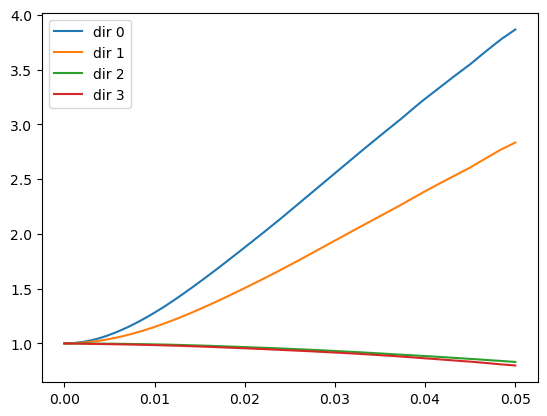

In [3694]:
n_iterations_ly = 250
tmax = .05
h = tmax/n_iterations


block_sampling = 1
block_depth = 1
random_sampling = 0

sampling_mean = tensor([0.1,0,0,0],dtype=torch.float64)
sampling_delta0 = 1e-4


time_grid = np.linspace(0,tmax,n_iterations_ly)

if block_sampling == 1:
    if block_depth == 1:
        qblock = torch.zeros([5,4])
        qblock[0,:] = sampling_mean
        for dim_i in range(4):
            dim_temp = torch.zeros(4)
            dim_temp[dim_i] = 1
            qblock[dim_i+1] = sampling_mean + sampling_delta0 * dim_temp
    else:
        print("implement this please")
elif random_sampling == 1:
    print("implement this please")
else:
    print("choose a sampling method.")

#model(qblock)
def qdd_t_v(qblock):
    return QDD_true_v(qblock[:,:2].mT,qblock[:,2:].mT,m1,m2,l1,l2).mT
#QDD_true_v(qblock[:,:2].mT,qblock[:,2:].mT,m1,m2,l1,l2).mT

def qdd_t(qvec):
    return QDD_true(qvec[:2], qvec[2:],m1,m2,l1,l2)

def SHO(qblock):
    return (-1/l1)*sin(qblock[:,:2])


qblock_store = torch.zeros([5,4,n_iterations_ly])

for i in range(n_iterations_ly):
    qblock_store[:,:,i] = qblock
    #qdd_block = qdd_t_v(qblock)
    qdd_block = model(qblock)
    #qdd_block = SHO(qblock)
    qblock[:,:2] += h*qblock[:,2:]
    qblock[:,2:] += h*qdd_block
qblock_store = qblock_store.detach().cpu()

deltas = torch.zeros([4,n_iterations_ly])
ly = torch.zeros(4)

for j in range(4):
    for i in range(n_iterations_ly):
        deltas[j,i] = torch.norm(qblock_store[0,:,i] - qblock_store[j+1,:,i])
    ly[j] = (mean(torch.diff(log(deltas[j,int(n_iterations_ly/100):])/(h))))
    

torch.set_printoptions(precision=1,sci_mode=True)
#print(f"{ly.sort().values}")
print(f"{ly}")

for j in range(4):
    plt.plot(time_grid,(deltas[j,:])/(sampling_delta0),label=f"dir {j}")




plt.legend()
plt.show()





In [3662]:
#Calculating Jacobians from qdd, storing maximum matrix elements. Comparing true and model performance.

#jtrue = jacrev(qdd_t)

e0 = tensor([1,0,0,0],dtype=torch.float)
e1 = tensor([0,1,0,0],dtype=torch.float)
e2 = tensor([0,0,1,0],dtype=torch.float)
e3 = tensor([0,0,0,1],dtype=torch.float)

e0small = tensor([1,0],dtype=torch.float)
e1small = tensor([0,1],dtype=torch.float)

def qdd_test(qvec): #for testing if output is as expected for alpha=0
    l1, m1, l2, m2 = tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.])
    t0 = sum(e0*qvec)
    t1 = sum(e1*qvec)
    tdot0 = sum(e2*qvec)
    tdot1 = sum(e3*qvec)
    t0.requies_grad = True
    t1.requies_grad = True
    tdot0.requies_grad = True
    tdot1.requies_grad = True
    
    tdd1 = -g*(2*m1+m2)*sin(t0) - m2*g*sin(t0-2*t1) - 2*sin(t0-t1)*m2*(l2*tdot1**2 + l1*(tdot0**2)*cos(t0-t0))
    tdd1_out = tdd1 / (l1* (2*m1 + m2 - m2*cos(2*t0 - 2*t1) ) )
    tdd2 = 2*sin(t0-t1)*( (m1+m2)*l1*tdot0**2 + g*(m1+m2)*cos(t0) + l2*m2*cos(t0-t1)*tdot1**2 )
    tdd2_out = tdd2 / ( l2 * (2*m1 + m2 - m2*cos(2*t0 - 2*t0)) )
    #out = tensor([tdd1_out,tdd2_out],requires_grad=True)
    out = torch.cat((tdd1_out, tdd2_out))
    return out
    
def deriv_mat_model(qvec):
    dd = model(qvec)
    return e0*sum(e2*qvec) + e1*sum(e3*qvec) + e2*sum(e0small*dd) + e3*sum(e1small*dd)

def deriv_mat_true(qvec):
    dd = qdd_t(qvec)
    return e0*sum(e2*qvec) + e1*sum(e3*qvec) + e2*sum(e0small*dd) + e3*sum(e1small*dd)

def deriv_mat_test(qvec):
    dd = qdd_test(qvec)
    out = e0*sum(e2*qvec) + e1*sum(e3*qvec) + e2*sum(e0small*dd) + e3*sum(e1small*dd)
    return out
    
jmodel = jacrev(deriv_mat_model)
#jtrue = jacrev(deriv_mat_true)
jtrue = jacrev(deriv_mat_test)

m_elem_max_true = torch.zeros([4,4])
max_eigs_true = torch.zeros(4)
min_eigs_true = torch.zeros(4)
m_elem_max_model = torch.zeros([4,4])
max_eigs_model = torch.zeros(4)
min_eigs_model = torch.zeros(4)

n_guesses = 300

for i in range(n_guesses):
    test_vec = 2*torch.randn(4,requires_grad=True)
    iter_jac_true = jtrue(test_vec)
    iter_jac_model = jmodel(test_vec)
    eigvals_true = abs(torch.linalg.eig(iter_jac_true).eigenvalues)
    eigvals_model = abs(torch.linalg.eig(iter_jac_model).eigenvalues)
    max_eigs_true = max(eigvals_true, max_eigs_true )
    max_eigs_model = max(eigvals_model, max_eigs_model )
    for inner in range(4):
        min_eigs_true[inner] = min(eigvals_true[inner], min_eigs_true[inner])
        min_eigs_model[inner] = min(eigvals_model[inner], min_eigs_model[inner])
    m_elem_max_true = max(abs(iter_jac_true),m_elem_max_true)
    m_elem_max_model = max(abs(iter_jac_model),m_elem_max_model)


torch.set_printoptions(precision=1,sci_mode=False)
np.set_printoptions(precision=1)

print("True system: -----------------------------------------")
print(f"\nmaximum matrix elements:\n{m_elem_max_true.data.numpy()}")
print(f"\nmaximum eigenvalues:\n{max_eigs_true.data.numpy()}")

print("\n\nModel system: ----------------------------------------")
print(f"\nmaximum matrix elements:\n{m_elem_max_model.data.numpy()}")
print(f"\nmaximum eigenvalues:\n{max_eigs_model.data.numpy()}")

print("\n\nComparison (%relative errors on non-zero items): ------------------------")
display_matrix_elements = torch.zeros([4,4])
display_matrix_elements[2:,:] = 100*(m_elem_max_model - m_elem_max_true)[2:,:]/m_elem_max_true[2:,:]

print(f"\nmaximum matrix elements:\n{display_matrix_elements.detach().numpy()}")
print(f"\nmaximum eigenvalues:\n{(100*(max_eigs_model - max_eigs_true)/max_eigs_true).detach().numpy()}")


True system: -----------------------------------------

maximum matrix elements:
[[ 0.   0.   1.   0. ]
 [ 0.   0.   0.   1. ]
 [34.5 36.8  5.2  6.3]
 [65.8 65.7 20.5  6. ]]

maximum eigenvalues:
[11.4  9.6  5.6  7.8]


Model system: ----------------------------------------

maximum matrix elements:
[[ 0.   0.   1.   0. ]
 [ 0.   0.   0.   1. ]
 [38.8 31.1  3.7  7. ]
 [53.3 53.3 11.   5.7]]

maximum eigenvalues:
[9.4 9.3 5.7 8.1]


Comparison (%relative errors on non-zero items): ------------------------

maximum matrix elements:
[[  0.    0.    0.    0. ]
 [  0.    0.    0.    0. ]
 [ 12.5 -15.4 -27.8  12.4]
 [-18.9 -18.8 -46.4  -5.3]]

maximum eigenvalues:
[-17.7  -4.    1.5   4.1]


***Calculating Lyapunov spectrum*** **Note -- not working as expected -- likely an issue somewhere. I need more background on these kinds of calculations.**

Procedure from Wikipedia: https://en.wikipedia.org/wiki/Lyapunov_exponent

Let $J_{ij}(t)=\frac{df_i(x)}{dx_j}|_{x(t)}$ be the Jacobian at a given point in time/evolution.

Then let $Y$ be a $4\times4$ matrix s.t. $\dot{Y} = JY$, where $Y(0) = \delta_{ij}$. This matrix represents the action of the diff. eq. flow on small perturbations in the region around a given condition.

In the infinite + continuous time example,
$$
\Lambda = \lim_{t\to\inf} \frac{1}{2t} \log \Big( Y(t) Y(t)^T \Big)
$$

Here, 
$$
\Lambda(t_{max})= \frac{1}{2t_{max}} \log \Big( Y(t_{max}) Y(t_{max})^T \Big)
$$

Where the eigenvalues of $\Lambda$ $\lambda_i$ are the Lyapunov exponents.

100%|██████████| 150/150 [00:29<00:00,  5.15it/s]


tensor(0.0)
tensor(9.4)


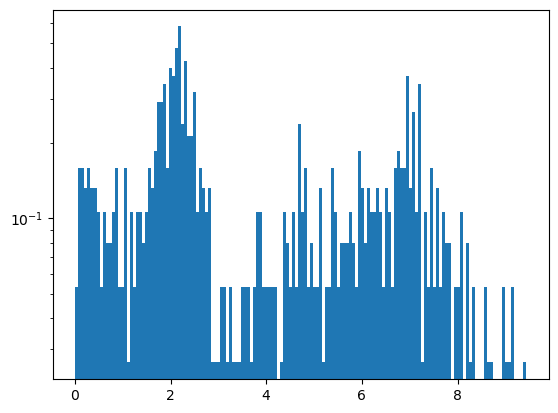

In [3674]:
from scipy.linalg import logm


def qdd_fixed(qtot):
    return QDD_true(qtot[:2],qtot[2:],m1,m2,l1,l2)

def matrix_log(mat): #assumes n x n matrix
    values, vectors = torch.linalg.eig(mat) #vectors is the n x n matrix with eigenvectors as columns
    
    log_values = log(values)
    log_Aprime = torch.zeros(mat.shape,dtype = vectors.dtype)
    for i in range(mat.shape[0]):
        log_Aprime[i,i] = log_values[i]
    vectors_inv = torch.linalg.inv(vectors)
    log_mat = vectors@log_Aprime@vectors_inv
    return log_mat

n_euler_iterations = 300
n_conditions = 150

cond_spread = .1
#cond_mean = tensor([torch.pi/2,torch.pi/2,0,0])
#cond_mean = 100*torch.randn(4)

tmax = 0.25

h = tmax/n_euler_iterations

model.eval()

ly_store = torch.zeros([4,n_conditions])

for cond in trange(n_conditions):
    cond_mean = 1*torch.randn(4)
    qtot = cond_spread*torch.randn(4) + cond_mean
    #print(f"initial condition: {qtot}")
    Y = torch.eye(4)
    
    qstore = torch.zeros(4,n_euler_iterations)
    qstore[:,0] = qtot
    
    for i in range(1,n_euler_iterations):
        iter_jac_true = jtrue(qtot)
        Y += h*iter_jac_true@Y #iteratively update Y
        qdd = qdd_fixed(qtot)
        qtot[:2] += h*qtot[2:]
        qtot[2:] += h*qdd
        qstore[:,i] = qtot
        
    qstore = qstore.cpu().detach().numpy()
    lambda_matrix = (1/(2*tmax)) * matrix_log(Y@Y.mT)
    #lambda_matrix = torch.tensor((1/(2*tmax)) * logm((Y@Y.mT).detach().cpu().numpy()))
    
    #print(f"lambda mat:\n{torch.abs(lambda_matrix)}")
    #print(f"rank(lambda mat): {torch.linalg.matrix_rank(lambda_matrix)}")
    #print(f"Y mat:\n{Y}")
    #print(f"rank(Y mat): {torch.linalg.matrix_rank(Y)}")
    #print(f"YY mat:\n{Y@Y.mT}")


    ly = torch.abs(torch.linalg.eig(lambda_matrix).eigenvalues)
    ly_store[:,cond] = ly
    #print(f"Lyapunov exponents: {torch.abs(torch.linalg.eig(lambda_matrix).eigenvalues)}\n\n")
    
print(ly_store.min())
print(ly_store.max())
#print(mean(ly_store,axis=1))
#print(std(ly_store,axis=1))

#plt.legend(loc='right')
#plt.show()

plt.hist(ly_store.reshape(-1),density=True,bins=150)
plt.yscale('log')
plt.show()

In [3338]:
torch.eye(4)

tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])

4